# Medical Image Segmentation with SAM and MedSAM2

In this lab we use SAM (Segment Anything Model), a promptable segmentation
model, adapt it to brain-tumour segmentation on multi-modal MRI (the BraTS
dataset), and finish with MedSAM2 for 3D segmentation.

By the end of the session you should be able to:

1. Describe the three components of the SAM architecture and why it is promptable.
2. Load and explore 3D medical volumes (NIfTI) with `SimpleITK`.
3. Build a PyTorch `Dataset` / `DataLoader` for 2D slices extracted from 3D volumes.
4. Run SAM zero-shot with point and box prompts, and see why prompt design matters
   in medical imaging.
5. Finetune SAM's mask decoder with box prompts derived from the ground truth.
6. Benchmark against a small U-Net baseline.
7. Run MedSAM2 for 3D segmentation from a single box prompt via memory
   propagation, and compare 2D and 3D approaches on the held-out test set.

Sections marked *Exercise* are for you to complete; *Discussion* are short
reflection prompts; *Bonus* are optional.

A promptable model such as SAM needs a prompt at every step: passing an empty
prompt to the prompt encoder makes the decoder collapse to a single average
mask. Throughout this lab, every prediction and every training step is driven
by a box prompt derived from the segmentation.

Throughout the notebook, cells contain lines marked `# FILL` that you must complete. Each is preceded by a short **FILL** note describing what is expected. Everything else (data loading, plotting, helpers) is provided.


## 1. Setting up the environment

We install the [official SAM codebase](https://github.com/facebookresearch/segment-anything)
and a few medical-imaging utilities. Versions are pinned where Colab, SAM and
`ipywidgets` interact badly.


In [ ]:
# --- Core model + medical IO ---
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q SimpleITK scikit-image
!pip install -q -q ipympl
!pip install -q --upgrade ipympl ipywidgets
#get_ipython().kernel.do_shutdown(restart=True)
from google.colab import output
output.enable_custom_widget_manager()
%matplotlib widget


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 13.5 MB/s eta 0:00:00


ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

If you are on a GPU partition, restart the session (`Runtime > Restart session`)
after this install step and re-run from here, otherwise the interactive
`%matplotlib widget` cells later misbehave. MedSAM2 is installed later, in its
own section, since it needs a separate SAM2 codebase.


In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import SimpleITK as sitk
import ipywidgets as widgets
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from IPython.display import clear_output
from torchvision.transforms import Resize
from ipywidgets import Button, HBox, Output
from segment_anything import build_sam_vit_b, SamPredictor

%matplotlib inline

# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Computing on {device}.')


Computing on cuda.


## 2. Understanding the model

### 2.1. SAM architecture

SAM ([ICCV 2023](https://arxiv.org/pdf/2304.02643)) is a Transformer-based
architecture for promptable image segmentation, with three components:

- Image encoder: a ViT that encodes the image into an embedding, computed once
  per image (the expensive part).
- Prompt encoder: embeds prompts (points, boxes, masks) into a common space (cheap).
- Mask decoder: a lightweight Transformer decoder that fuses image and prompt
  embeddings to predict a mask and an IoU/confidence score. Its attention pattern is
  self-attention on the prompt tokens, cross-attention prompt to image, and
  cross-attention image to prompt.

![SAM diagram](https://github.com/facebookresearch/segment-anything/raw/main/assets/model_diagram.png?raw=true)

The image encoder is heavy (~90M params) but runs once, while the prompt encoder
and mask decoder are small (~4M params) and run per prompt. This is why
finetuning only the decoder is cheap and fast.

### 2.2. SAM training

SAM was trained in three stages (assisted, semi-automatic, fully automatic),
producing the SA-1B dataset of ~11M images and ~1.1B masks. SA-1B is made of
natural images with essentially no medical imaging, and this domain gap is the
motivation for MedSAM.


In [ ]:
model = build_sam_vit_b('sam_vit_b_01ec64.pth')
print(f"Total parameters:        {sum(p.numel() for p in model.parameters()):,}")
print(f"Image encoder params:    {sum(p.numel() for p in model.image_encoder.parameters()):,}")
print(f"Prompt encoder params:   {sum(p.numel() for p in model.prompt_encoder.parameters()):,}")
print(f"Mask decoder params:     {sum(p.numel() for p in model.mask_decoder.parameters()):,}")


Total parameters:        93,735,472
Image encoder params:    89,670,912
Prompt encoder params:   6,220
Mask decoder params:     4,058,340


Discussion. Look at the parameter counts above. Roughly what fraction of the
model is the mask decoder, and why does that make decoder-only finetuning cheap
and fast?


The image encoder is a standard ViT, composed of multiple ViT encoder blocks.


In [ ]:
print(model.image_encoder)

ImageEncoderViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): MLPBlock(
        (lin1): Linear(in_features=768, out_features=3072, bias=True)
        (lin2): Linear(in_features=3072, out_features=768, bias=True)
        (act): GELU(approximate='none')
      )
    )
  )
  (neck): Sequential(
    (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): LayerNorm2d()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): LayerNorm2d()
  )
)


The mask decoder is mainly composed of self-attention on the prompts and cross-attention in both directions (image $\rightarrow$ prompt and prompt $\rightarrow$ image).


In [ ]:
print(model.mask_decoder)

MaskDecoder(
  (transformer): TwoWayTransformer(
    (layers): ModuleList(
      (0-1): 2 x TwoWayAttentionBlock(
        (self_attn): Attention(
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (k_proj): Linear(in_features=256, out_features=256, bias=True)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (cross_attn_token_to_image): Attention(
          (q_proj): Linear(in_features=256, out_features=128, bias=True)
          (k_proj): Linear(in_features=256, out_features=128, bias=True)
          (v_proj): Linear(in_features=256, out_features=128, bias=True)
          (out_proj): Linear(in_features=128, out_features=256, bias=True)
        )
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
         

## 3. **Database**

We use a preprocessed slice-wise version of **BraTS19** (Brain Tumour Segmentation challenge): multi-modal brain MRI with expert tumour annotations.


### 3.1. Download the database


In [ ]:
!git clone -q https://github.com/soniamartinot/GEP1.git || echo 'already cloned'

fatal: destination path 'GEP1' already exists and is not an empty directory.
already cloned


### 3.2. Overview of the database

The data lives in `/GEP1/`:

**`origin_data`** — 4 patients, one whole NIfTI volume per modality, shape `(155, 192, 192)`.

**`data`** — 336 patients, preprocessed to shape `(78, 96, 96)` for fast training. For each patient `BraTS19_EXAMPLE`, the folder `/GEP1/data/BraTS19_EXAMPLE` holds one NIfTI per modality **per Z slice** (78 slices/modality).


In [ ]:
data_path = './GEP1/data/'
original_data_path = './GEP1/origin_data/'

#### 3.2.1. Inside of the database


In [ ]:
# Original data
print("Content of the folder:\n", os.listdir(original_data_path))
patient = "BraTS19_TCIA01_131_1"
print("Content of a patient's folder:\n", os.listdir(os.path.join(original_data_path, patient)))

Content of the folder:
 ['BraTS19_CBICA_ANP_1', 'BraTS19_TCIA10_442_1', 'BraTS19_CBICA_AWV_1', 'BraTS19_TCIA01_131_1']
Content of a patient's folder:
 ['BraTS19_TCIA01_131_1_t2.nii.gz', 'BraTS19_TCIA01_131_1_t1ce.nii.gz', 'BraTS19_TCIA01_131_1_t1.nii.gz', 'BraTS19_TCIA01_131_1_flair.nii.gz', 'BraTS19_TCIA01_131_1_seg.nii.gz']


In [ ]:
# Processed data
files = os.listdir(data_path)
print('First 5 patient folders:\n', files[:5])
print('Number of files for one patient :', len(os.listdir(os.path.join(data_path, files[0]))))
print('Number of patients in {} : {}'.format(data_path, len(files)))

First 5 patient folders:
 ['BraTS19_TCIA01_378_1', 'BraTS19_CBICA_AQO_1', 'BraTS19_CBICA_BLJ_1', 'BraTS19_CBICA_AYC_1', 'BraTS19_CBICA_AQN_1']
Number of files for one patient : 390
Number of patients in ./GEP1/data/ : 336


#### 3.2.2. Inside of a patient's folder

Each patient has **4 modalities + the segmentation**, with one file per Z slice (78 slices):

- **T1** — anatomical
- **T2** — fluid-sensitive
- **T1ce (Gado)** — contrast-enhanced, highlights active tumour
- **FLAIR** — suppresses CSF, highlights oedema
- **seg** — expert label (0 background, 1 necrotic core, 2 oedema, 4 enhancing tumour)


In [ ]:
modalities = ['t1', 't2', 't1ce', 'flair', 'seg']

In [ ]:
patient = 'BraTS19_2013_20_1'
patient_path = os.path.join(data_path, patient)
patient_files = os.listdir(patient_path)
print(len(patient_files), 'files')
patient_files[:10]

390 files


['BraTS19_2013_20_1_flair_z_52.nii.gz',
 'BraTS19_2013_20_1_seg_z_57.nii.gz',
 'BraTS19_2013_20_1_seg_z_68.nii.gz',
 'BraTS19_2013_20_1_t1_z_56.nii.gz',
 'BraTS19_2013_20_1_t1_z_66.nii.gz',
 'BraTS19_2013_20_1_t1ce_z_35.nii.gz',
 'BraTS19_2013_20_1_flair_z_70.nii.gz',
 'BraTS19_2013_20_1_t2_z_77.nii.gz',
 'BraTS19_2013_20_1_flair_z_75.nii.gz',
 'BraTS19_2013_20_1_t1ce_z_38.nii.gz']

In [ ]:
# Filter for the FLAIR modality
flair_modality_files = sorted([e for e in patient_files if 'flair' in e])
print("Number of Z slices:", len(flair_modality_files))
flair_modality_files[-5:]

Number of Z slices: 78


['BraTS19_2013_20_1_flair_z_75.nii.gz',
 'BraTS19_2013_20_1_flair_z_76.nii.gz',
 'BraTS19_2013_20_1_flair_z_77.nii.gz',
 'BraTS19_2013_20_1_flair_z_8.nii.gz',
 'BraTS19_2013_20_1_flair_z_9.nii.gz']

#### 3.2.3. SimpleITK tutorial

We read NIfTI files with **`SimpleITK`**. To open an image:

    image = sitk.ReadImage(image_path)

You can query physical metadata:
- spacing: `image.GetSpacing()`
- direction: `image.GetDirection()`
- origin: `image.GetOrigin()`
- size: `image.GetSize()`
- a pixel value: `image.GetPixel(x, y, z)`

And convert to a NumPy array (note: **axes are reversed** — `sitk` is `(x,y,z)`, the array is `(z,y,x)`):

    array = sitk.GetArrayFromImage(image)


In [ ]:
patient = 'BraTS19_CBICA_ANP_1'
modality = 'flair'
patient_folder = os.path.join(original_data_path, patient)
image_name = f"{patient}_{modality}.nii.gz"
image_path = os.path.join(patient_folder, image_name)
print("Path to the image:", image_path)
image = sitk.ReadImage(image_path)
print("Type of the opened image:", type(image))

Path to the image: ./GEP1/origin_data/BraTS19_CBICA_ANP_1/BraTS19_CBICA_ANP_1_flair.nii.gz
Type of the opened image: <class 'SimpleITK.SimpleITK.Image'>


In [ ]:
print('Image Direction :', image.GetDirection())
print('Image Spacing   :', image.GetSpacing())
print('Image Origin    :', image.GetOrigin())
print('Image Size      :', image.GetSize())
print('Pixel (0,0,0)   :', image.GetPixel(0, 0, 0))

Image Direction : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Image Spacing   : (1.0, 1.0, 1.0)
Image Origin    : (-0.0, -239.0, 0.0)
Image Size      : (240, 240, 155)
Pixel (0,0,0)   : 0


In [ ]:
array = sitk.GetArrayFromImage(image)
print("Type :", type(array))
print("Shape (z, y, x):", array.shape)
print("First voxel    :", array[0, 0, 0])

Type : <class 'numpy.ndarray'>
Shape (z, y, x): (155, 240, 240)
First voxel    : 0


#### 3.2.4. Comparison between original data and preprocessed data

The original `(155, 240, 240)` images were preprocessed:
- Cropped to `(155, 192, 192)`
- Downsampled by interpolation (scale 0.5) to `(78, 96, 96)`
- Saved with each Z slice **independently** as a `(96, 96)` array.


Original array shape : (155, 240, 240)
Processed array shape : (96, 96)


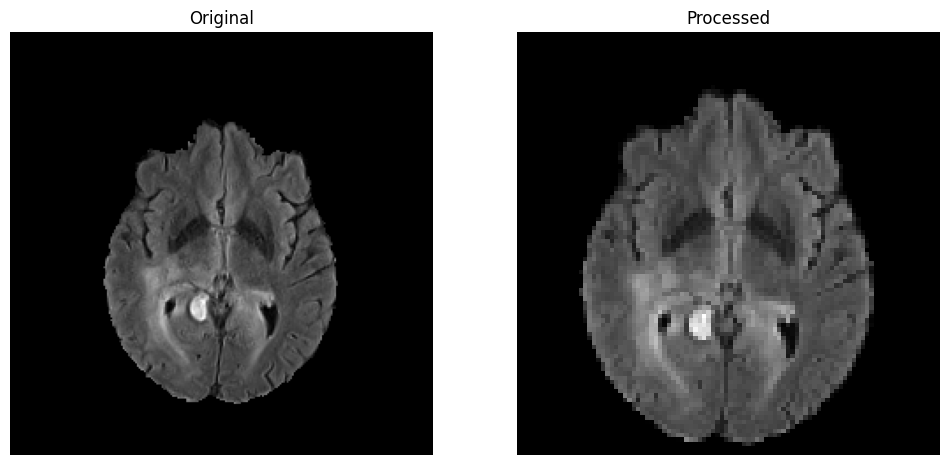

In [ ]:
patient = 'BraTS19_CBICA_ANP_1'
modality = 'flair'

# original volume
image = sitk.ReadImage(os.path.join(original_data_path, patient, f"{patient}_{modality}.nii.gz"))
orig_array = sitk.GetArrayFromImage(image)
print('Original array shape :', orig_array.shape)

# one preprocessed slice
z_slice = 35
path = os.path.join(data_path, patient, f"{patient}_{modality}_z_{z_slice}.nii.gz")
processed_array = sitk.GetArrayFromImage(sitk.ReadImage(path))
print('Processed array shape :', processed_array.shape)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(orig_array[z_slice*2], cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(processed_array, cmap='gray'); plt.title('Processed'); plt.axis('off')
plt.show()

#### 3.2.5. Visualize all modalities

Plot every modality side by side, iterating over slices. (Run, watch the tumour appear/disappear across slices, then interrupt the cell.)


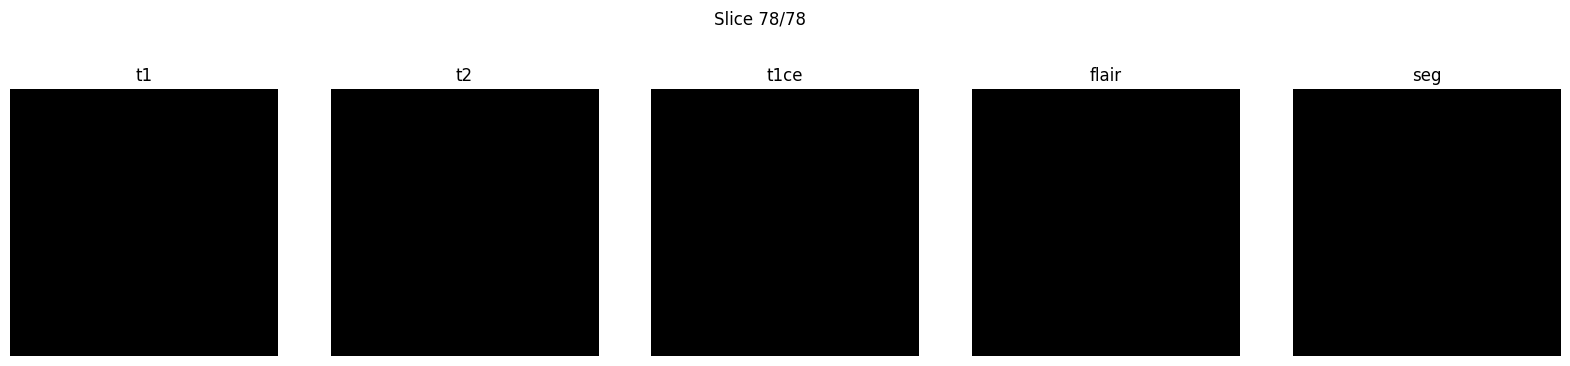

In [ ]:
patient = 'BraTS19_2013_20_1'
flair_modality_files = sorted([e for e in os.listdir(os.path.join(data_path, patient)) if 'flair' in e])

for z in range(len(flair_modality_files)):
    f, axes = plt.subplots(1, 5, figsize=(20, 6))
    for i, modality in enumerate(modalities):
        file_path = os.path.join(data_path, patient, f"{patient}_{modality}_z_{z}.nii.gz")
        sl = sitk.GetArrayFromImage(sitk.ReadImage(file_path))
        axes[i].set_title(modality)
        axes[i].imshow(sl, cmap="gray"); axes[i].axis('off')
    plt.suptitle(f"Slice {z+1}/{len(flair_modality_files)}", y=0.85)
    plt.show()
    clear_output(wait=True)

### 3.3. Creating the train / validation / test sets

The split is stored in `/GEP1/datasets/` as one text file per split listing patient IDs.


In [ ]:
datasets_path = './GEP1/datasets/'

train_set = np.loadtxt(datasets_path + 'train.txt', dtype=str)
validation_set = np.loadtxt(datasets_path + 'val.txt', dtype=str)
test_set = np.loadtxt(datasets_path + 'test.txt', dtype=str)

print('Train set, first 5 patients :', train_set[:5], '\n')
print('Train set length      :', len(train_set))
print('Validation set length :', len(validation_set))
print('Test set length       :', len(test_set))

Train set, first 5 patients : ['BraTS19_CBICA_BHQ_1' 'BraTS19_CBICA_AQV_1' 'BraTS19_CBICA_ATN_1'
 'BraTS19_TCIA01_335_1' 'BraTS19_CBICA_ASY_1'] 

Train set length      : 251
Validation set length : 42
Test set length       : 42


 Discussion. The split is **patient-wise**, not slice-wise. Why is it critical that all slices of a given patient stay in the same split? (Hint: think about what "data leakage" would mean for adjacent slices of the same brain.)


## 4. Dataset creation

We now build the PyTorch data pipeline. The dataset returns a bounding-box prompt
derived from the ground-truth mask, in addition to the image and mask. This box
is fed to SAM's prompt encoder both at inference (Section 5) and during
finetuning (Section 6).


### 4.1. Helper functions

The utilities below include `mask_to_box`, which converts a binary mask into a
bounding box with a small random perturbation, following the box-simulation
strategy used to train MedSAM (Ma et al., 2024), where boxes were derived from
expert annotations with a 0–20 px perturbation.


In [ ]:
end = '.nii.gz'

def load_split(split_folder):
    """Return train, val, test patient lists."""
    train_split = np.loadtxt(os.path.join(split_folder, 'train.txt'), dtype=str)
    val_split   = np.loadtxt(os.path.join(split_folder, 'val.txt'),   dtype=str)
    test_split  = np.loadtxt(os.path.join(split_folder, 'test.txt'),  dtype=str)
    return train_split, val_split, test_split


def load_sitk(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(path))


def find_z_slice(list_patient, threshold, dataframe):
    """For each patient, return (patient, z) IDs for slices whose tumour area >= threshold."""
    list_IDs = []
    for patient in list_patient:
        if threshold > 0:
            condition = dataframe[patient].values >= threshold
            z_slice = np.where(condition)[0]
        else:
            z_slice = range(155)
        list_IDs += list(set([(patient, int(z // 2)) for z in z_slice]))
    return list_IDs


def generate_IDs(train_split, val_split, test_split,
                 tumor_percentage, csv_path, image_size=(240, 240)):
    tumor_volume_dataframe = pd.read_csv(csv_path)
    threshold = int(tumor_percentage * np.prod(image_size) / 100)
    train_IDs = find_z_slice(train_split, threshold, tumor_volume_dataframe)
    val_IDs   = find_z_slice(val_split,   threshold, tumor_volume_dataframe)
    test_IDs  = find_z_slice(test_split,  threshold, tumor_volume_dataframe)
    return train_IDs, val_IDs, test_IDs


def mask_to_box(mask, perturbation=5, img_size=None):
    """
    Convert a binary mask (H, W) into a bounding box [x_min, y_min, x_max, y_max]
    in *pixel* coordinates, with a small random perturbation (as in MedSAM).
    Returns None if the mask is empty.
    """
    mask = np.asarray(mask).squeeze()
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    H, W = mask.shape if img_size is None else img_size
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    if perturbation > 0:
        x_min = max(0,     x_min - np.random.randint(0, perturbation + 1))
        x_max = min(W - 1, x_max + np.random.randint(0, perturbation + 1))
        y_min = max(0,     y_min - np.random.randint(0, perturbation + 1))
        y_max = min(H - 1, y_max + np.random.randint(0, perturbation + 1))
    return np.array([x_min, y_min, x_max, y_max], dtype=float)


def dice_score(pred, target, eps=1e-6):
    """Hard Dice between two binary tensors/arrays (for *evaluation*, not training)."""
    ##FILL CODE


def save_checkpoint(state, save_path):
    os.makedirs(save_path, exist_ok=True)
    fn = os.path.join(save_path, 'model.{:02d}--{:.3f}.pth.tar'.format(state['epoch'], state['val_loss']))
    torch.save(state, fn)
    return fn


In [ ]:
# Box-prompted SAM inference on a native-resolution slice.
# Returns a binary mask in the slice's own pixel grid.
@torch.no_grad()
def sam_box_inference(sam_model, slice_2d, box_xyxy, device):
    sam_model.eval()
    rgb = np.stack([slice_2d] * 3, axis=-1).astype(np.float32)

    ##FILL CODE
    rgb = #should normalize the rgb image to [0, 255] range
    rgb = rgb.astype(np.uint8)

    ##FILL CODE
    predictor = #Instantiate a SamPredictor with the model on the specified device
    predictor.set_image(rgb)
    masks, _, _ = predictor.predict(
        box=np.asarray(box_xyxy, dtype=np.float32)[None, :],
        multimask_output=False,
    )
    return masks[0].astype(np.uint8)


### 4.2. Dataset class

The dataset:
1. loads the chosen MRI modalities for a given `(patient, z)` slice,
2. loads and binarises the segmentation (any tumour label to 1),
3. resizes image and mask to SAM's `1024x1024` input,
4. computes a bounding-box prompt from the resized mask.

It returns `(image, mask, box, patient_id)`.

Exercise. Read `__getitem__` and make sure you understand why the box is
computed after resizing, so its coordinates match the 1024x1024 image the
encoder sees.


In [ ]:
SAM_INPUT_SIZE = 1024

class SegmentationDataset(torch.utils.data.Dataset):
    """Returns (image[C,1024,1024], mask[1,1024,1024], box[4], patient_id)."""

    def __init__(self, files_list, data_path,
                 modalities=['t2', 't1ce', 'flair'],
                 box_perturbation=5):
        super().__init__()
        self.files_list = files_list
        self.data_path = data_path
        self.modalities = modalities
        self.box_perturbation = box_perturbation
        self.resize_img = Resize(SAM_INPUT_SIZE)
        # nearest-like resize for masks: we resize then re-threshold
        self.resize_mask = Resize(SAM_INPUT_SIZE)

    def __len__(self):
        return len(self.files_list)

    def load(self, ID):
        patient, z_slice = ID
        patient_path = os.path.join(self.data_path, patient)

        irm = []
        for modality in self.modalities:
            fn = f"{patient}_{modality}_z_{z_slice}.nii.gz"
            irm.append(load_sitk(os.path.join(patient_path, fn)))
        irm = np.stack(irm, axis=0).astype(np.float32)        # (C, H, W)

        seg_name = f"{patient}_seg_z_{z_slice}.nii.gz"
        mask = load_sitk(os.path.join(patient_path, seg_name)).astype(np.float32)
        mask[mask > 0] = 1.0                                  # binarise: whole tumour
        mask = np.expand_dims(mask, 0)                        # (1, H, W)
        return irm, mask

    def __getitem__(self, idx):
        ID = self.files_list[idx]
        irm, mask = self.load(ID)

        irm  = self.resize_img(torch.tensor(irm))             # (C, 1024, 1024)
        mask = (self.resize_mask(torch.tensor(mask)) > 0.5).float()  # (1, 1024, 1024)

        box = mask_to_box(mask[0].numpy(), perturbation=self.box_perturbation)
        if box is None:                                       # safety: empty mask -> full-image box
            box = np.array([0, 0, SAM_INPUT_SIZE - 1, SAM_INPUT_SIZE - 1], dtype=float)
        box = torch.tensor(box, dtype=torch.float32)          # (4,)

        return irm, mask, box, ID


### 4.3. Creating the split and generating the slice-index lists

`train_IDs`, `val_IDs`, `test_IDs` are the `(patient, z)` lists passed as `files_list`.


In [ ]:
datasets_path = './GEP1/datasets/'
csv_path = './GEP1/data/tumor_count.csv'

# Only keep slices whose tumour occupies at least this % of the image.
tumour_percentage = 0.5
train_split, val_split, test_split = load_split(datasets_path)
train_IDs, val_IDs, test_IDs = generate_IDs(train_split, val_split, test_split,
                                            tumour_percentage, csv_path)
print(f"train slices: {len(train_IDs)} | val slices: {len(val_IDs)} | test slices: {len(test_IDs)}")

train slices: 6791 | val slices: 1263 | test slices: 1155


In [ ]:
val_IDs[:5]

[(np.str_('BraTS19_TCIA01_499_1'), 18),
 (np.str_('BraTS19_TCIA01_499_1'), 21),
 (np.str_('BraTS19_TCIA01_499_1'), 24),
 (np.str_('BraTS19_TCIA01_499_1'), 30),
 (np.str_('BraTS19_TCIA01_499_1'), 27)]

### 4.4. Instantiate the datasets

We use 3 modalities (T2, T1ce, FLAIR) so the stacked input has 3 channels — convenient because SAM expects a 3-channel image.


In [ ]:
modalities = ['t2', 't1ce', 'flair']
train_dataset = SegmentationDataset(train_IDs, data_path=data_path, modalities=modalities)
val_dataset   = SegmentationDataset(val_IDs,   data_path=data_path, modalities=modalities, box_perturbation=0)
test_dataset  = SegmentationDataset(test_IDs,  data_path=data_path, modalities=modalities, box_perturbation=0)

Calling `train_dataset[0]` runs `__getitem__`. Inspect the shapes and the box.


In [ ]:
image, mask, box, pid = train_dataset[0]
print("Image shape :", tuple(image.shape))
print("Mask shape  :", tuple(mask.shape))
print("Box [x0,y0,x1,y1]:", box.numpy())
print("Patient     :", pid[0], "| slice:", pid[1])

Image shape : (3, 1024, 1024)
Mask shape  : (1, 1024, 1024)
Box [x0,y0,x1,y1]: [689. 512. 868. 695.]
Patient     : BraTS19_CBICA_BHQ_1 | slice: 40


### 4.5. DataLoaders


In [ ]:
batch_size = 4
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=1,          shuffle=False, drop_last=False)

## 5. SAM zero-shot on the data (baseline)

Before training, we look at what off-the-shelf SAM does on a brain-MRI slice with
different prompts. This builds intuition about promptability and about the
natural-image to medical domain gap.


### 5.1. Read a slice and build the SAM predictor

SAM expects an 8-bit-style RGB image. We normalise the FLAIR slice to `[0, 255]`
and stack it into three channels.


In [ ]:
patient = 'BraTS19_CBICA_ANP_1'
z_slice = 35
modality = 'flair'
path = os.path.join(data_path, patient, f"{patient}_{modality}_z_{z_slice}.nii.gz")
processed_array = sitk.GetArrayFromImage(sitk.ReadImage(path))

# ground-truth mask for the same slice (for comparison + box prompt)
seg_path = os.path.join(data_path, patient, f"{patient}_seg_z_{z_slice}.nii.gz")
gt_mask = sitk.GetArrayFromImage(sitk.ReadImage(seg_path))
gt_mask = (gt_mask > 0).astype(np.uint8)
print("Slice shape:", processed_array.shape, "| tumour pixels:", int(gt_mask.sum()))

Slice shape: (96, 96) | tumour pixels: 278


In [ ]:
# Vanilla SAM predictor, kept only for the point-prompt demos in 5.3 / 5.4.
predictor = SamPredictor(model.to(device))

rgb_img = np.stack([processed_array] * 3, axis=-1).astype(np.float32)
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8) * 255.
rgb_img = rgb_img.astype(np.uint8)
predictor.set_image(rgb_img)   # runs the (expensive) image encoder once


### 5.2. Zero-shot with a box prompt derived from the ground truth

This is the MedSAM-style prompt. We compute the tumour bounding box on the native
96x96 slice; the predictor handles internal rescaling via `set_image`.

> **FILL.** Compute the tumour bounding box from `gt_mask` with `mask_to_box` (no perturbation at inference), then run `sam_box_inference` to get the predicted mask.


In [ ]:
# FILL: bounding box from the ground-truth mask (no perturbation at inference).
box = ...   # FILL  
print("Box prompt:", box)

# FILL: run box-prompted SAM inference on the slice.
pred_box = ...   # FILL  

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(processed_array, cmap='gray'); ax[0].set_title('FLAIR'); ax[0].axis('off')
ax[1].imshow(processed_array, cmap='gray')
ax[1].imshow(np.ma.masked_where(gt_mask == 0, gt_mask), alpha=0.5, cmap='autumn')
x0, y0, x1, y1 = box
ax[1].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='cyan', lw=2))
ax[1].set_title('Ground truth + box'); ax[1].axis('off')
ax[2].imshow(processed_array, cmap='gray')
ax[2].imshow(np.ma.masked_where(pred_box == 0, pred_box), alpha=0.5, cmap='winter')
ax[2].set_title(f'SAM (box)  Dice={dice_score(pred_box, gt_mask):.3f}'); ax[2].axis('off')
plt.show()

### 5.3. Zero-shot with point prompts (interactive)

Compare to point prompts. The widget below lets you click left = positive (inside
tumour) and right = negative (outside). On Colab you may need to enable custom
widgets (next cell). If the widget does not work in your environment, skip to 5.4,
which uses programmatic points.


In [ ]:
%matplotlib widget

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
class PointSelector:
    def __init__(self, image):
        self.image = image
        self.pos_points, self.neg_points = [], []
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        self.ax.imshow(self.image, cmap='gray')
        self.pos_scatter = self.ax.scatter([], [], c='green', label='Positive', s=50)
        self.neg_scatter = self.ax.scatter([], [], c='red',   label='Negative', s=50)
        self.ax.legend(loc='upper right')
        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)

    def on_click(self, event):
        if event.inaxes != self.ax:
            return
        if event.button == 1:
            self.pos_points.append((event.xdata, event.ydata))
        elif event.button == 3:
            self.neg_points.append((event.xdata, event.ydata))
        self.update_plot()

    def update_plot(self):
        if self.pos_points:
            self.pos_scatter.set_offsets(self.pos_points)
        if self.neg_points:
            self.neg_scatter.set_offsets(self.neg_points)
        self.fig.canvas.draw_idle()

    def reset(self, b):
        self.pos_points, self.neg_points = [], []
        self.pos_scatter.set_offsets(np.empty((0, 2)))
        self.neg_scatter.set_offsets(np.empty((0, 2)))
        self.fig.canvas.draw_idle()

    def get_points(self):
        return {"positive": np.array(self.pos_points),
                "negative": np.array(self.neg_points)}


In [ ]:
# Colab only: enable custom widget manager. Comment out if not on Colab.
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

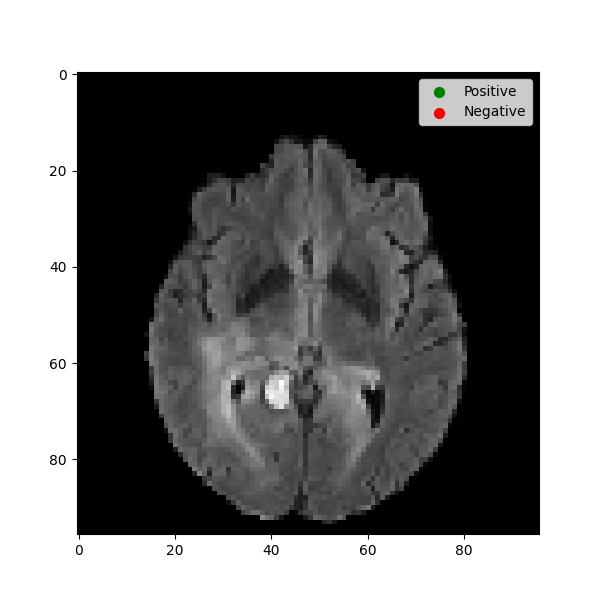

In [ ]:
selector = PointSelector(processed_array)
reset_button = Button(description="Reset Points")
reset_button.on_click(selector.reset)
display(HBox([reset_button]))

In [ ]:
annotated_points = selector.get_points()
pos_points = annotated_points['positive'].astype(int)
neg_points = annotated_points['negative'].astype(int)
assert len(pos_points) > 0, 'There must be at least one positive point.'
sam_points = np.concatenate([pos_points, neg_points]) if len(neg_points) else pos_points
sam_labels = np.concatenate([np.ones(len(pos_points)), np.zeros(len(neg_points))])

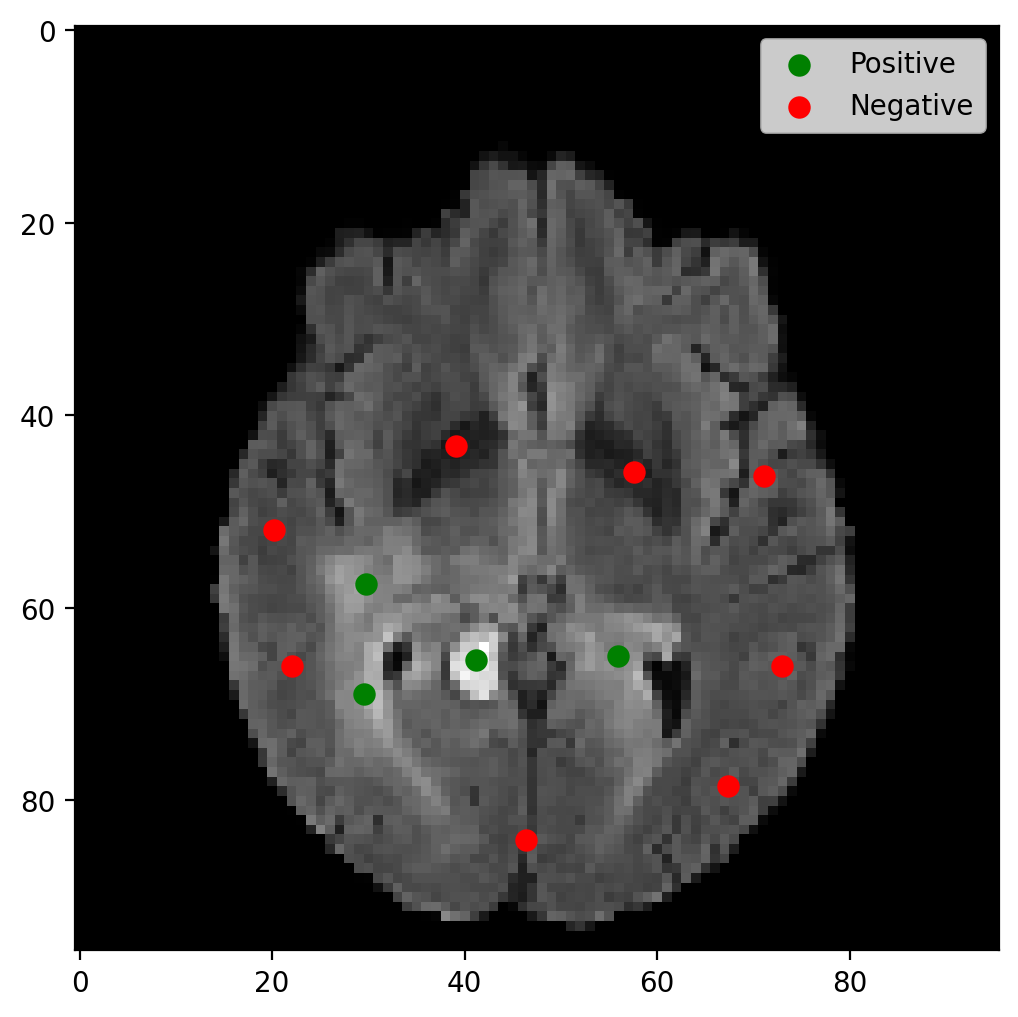

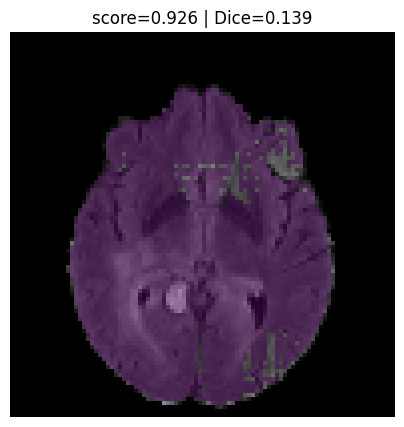

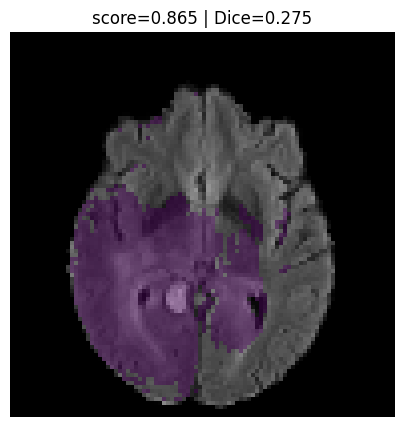

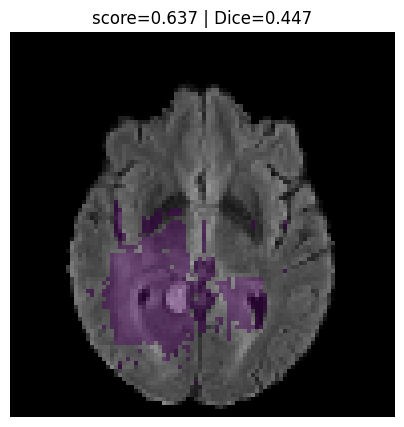

In [ ]:
%matplotlib inline
masks_pt, scores_pt, _ = predictor.predict(
    point_coords=sam_points,
    point_labels=sam_labels,
    multimask_output=True,
)
for m, s in zip(masks_pt, scores_pt):
    plt.figure(figsize=(5, 5))
    plt.imshow(processed_array, cmap='gray')
    plt.imshow(np.ma.masked_where(~m, ~m), alpha=0.5)
    plt.title(f"score={s:.3f} | Dice={dice_score(m, gt_mask):.3f}")
    plt.axis('off'); plt.show()

### 5.4. Exercise — box vs point, quantitatively

Without the widget, sample a positive point at the tumour centroid and a negative
point at an image corner, run SAM, and compare the Dice to the box prompt from
5.2. Fill in the gaps below.

> **FILL.** Build the point prompt: one positive point at the tumour centroid and one negative point in a corner, with the matching labels (1 = positive, 0 = negative).


In [ ]:
# centroid of the tumour
ys, xs = np.where(gt_mask > 0)
# FILL: positive point at the centroid, as a (1, 2) array of (x, y).
centroid = ...   # FILL  
corner   = np.array([[2, 2]])
pts    = np.concatenate([centroid, corner], axis=0)
# FILL: labels for [centroid, corner] -> [positive, negative].
labels = ...   # FILL  

masks_c, scores_c, _ = predictor.predict(point_coords=pts, point_labels=labels, multimask_output=True)
best = int(np.argmax([dice_score(m, gt_mask) for m in masks_c]))
print(f"Best point-prompt Dice : {dice_score(masks_c[best], gt_mask):.3f}")
print(f"Box-prompt Dice        : {dice_score(pred_box, gt_mask):.3f}")

Discussion. Which prompt type was more reliable on this slice? In an annotation
tool a box is one drag and a point is one click, but the box encodes extent while
the point does not. This is the main reason MedSAM standardised on boxes.


## 6. Finetuning the mask decoder

We finetune SAM (or MedSAM) on BraTS with the following strategy:

- Freeze the image encoder and the prompt encoder (already strong and expensive).
- Train only the mask decoder (~4M params).
- Drive every forward pass with a box prompt computed from the ground-truth mask
  (`mask_to_box`).

The box prompt flows into the prompt encoder on every step, so the decoder learns
to refine a mask given the box rather than predicting one global mask.


### 6.1. Loss function

For training we use a soft Dice loss on the sigmoid of the logits (the decoder
outputs logits, which must be squashed first), combined with BCE, following the
Dice+CE recipe used by MedSAM.

> **FILL.** Complete the soft Dice loss: squash the logits with a sigmoid, then form the soft intersection and union. The `dice_ce_loss` wrapper below is given.


In [ ]:
def soft_dice_loss(logits, target, smooth=1.0):
    """Soft Dice on probabilities. logits and target: (B, 1, H, W)."""
    # FILL: convert logits to probabilities in [0, 1].
    probs = ...   # FILL  
    target = target.float()
    probs_flat = probs.reshape(probs.shape[0], -1)
    target_flat = target.reshape(target.shape[0], -1)
    # FILL: soft intersection and union over the flattened pixels.
    inter = ...   # FILL  
    union = ...   # FILL  
    dice = (2. * inter + smooth) / (union + smooth)
    return 1. - dice.mean()


def dice_ce_loss(logits, target):
    bce = F.binary_cross_entropy_with_logits(logits, target.float())
    return soft_dice_loss(logits, target) + bce

Discussion. Why must we apply `sigmoid` before computing Dice? What happens
numerically if raw logits, which can be large and negative, are fed straight into
the Dice formula?


### 6.2. Full finetuning of the mask decoder

The mask decoder is small compared with the image encoder (see the parameter
counts in Section 2). Because it is only a few million parameters, we can
unfreeze all of its weights and let gradients flow into every parameter. We keep
the image encoder and prompt encoder frozen and feed a real box prompt on every
step.

Full finetuning gives the model maximum flexibility to adapt to BraTS and usually
reaches the best task-specific Dice, at the cost of training all decoder weights
and needing a lower learning rate and weight decay to stay stable.

> **FILL.** Set up decoder-only finetuning: first freeze every parameter, then re-enable gradients on the mask decoder only.


In [ ]:
import torch.nn as nn

# Build the finetuning model from SAM. We FULLY finetune the mask decoder:
# freeze the image encoder + prompt encoder, and train ALL mask-decoder weights.
finetune_model = copy.deepcopy(model).to(device)

# FILL: 1) freeze EVERY parameter of the model.
for p in finetune_model.parameters():
    ...   # FILL

# FILL: 2) unfreeze ALL parameters of the mask decoder.
for p in finetune_model.mask_decoder.parameters():
    ...   # FILL

finetune_model = finetune_model.to(device)

# Only the decoder params are trainable; collect them for the optimizer.
trainable_params = [p for p in finetune_model.mask_decoder.parameters() if p.requires_grad]

n_train = sum(p.numel() for p in trainable_params)
n_total = sum(p.numel() for p in finetune_model.parameters())
print(f"Full finetuning of the mask decoder: {n_train:,} trainable params "
      f"({100*n_train/n_total:.2f}% of the whole SAM model).")

learning_rate = 1e-4          # full finetuning needs a smaller LR than a PEFT adapter
criterion = dice_ce_loss
optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate, weight_decay=1e-4)

### 6.3. A single training/validation step with the box prompt

The box goes through the prompt encoder, the image encoder runs under `no_grad`,
and gradients flow only through the mask decoder.

> **FILL.** Complete the forward path inside the loop: encode the box with the prompt encoder, then decode a mask with the mask decoder. The box must drive the prompt encoder on every step.


In [ ]:
def single_step(batch, model, optimizer, criterion, device, mode):
    """One train/val step. Image -> [0,1] (MedSAM convention, NO mean/std preprocess).
    Dataset provides 1024x1024 images, 1024x1024 masks, and boxes in 1024-space."""
    images, masks, boxes, _ = batch                 # masks:(B,1,1024,1024) = LABELS
    images = images.to(device).float()
    masks  = masks.to(device).float()               # keep this name for the LABELS only
    boxes  = boxes.to(device).float()
    imgs = []
    for img in images:
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        imgs.append(img)
    imgs = torch.stack(imgs, dim=0)                  # (B, 3, 1024, 1024) in [0,1]

    with torch.no_grad():
        image_embeddings = model.image_encoder(imgs)

    is_train = (mode == 'train')
    grad_ctx = torch.enable_grad() if is_train else torch.no_grad()

    logits_list = []
    for emb, box in zip(image_embeddings, boxes):
        with torch.no_grad():
            # FILL: encode the box prompt. Pass the box (shape (1,1,4)); no points, no mask.
            sparse_emb, dense_emb = model.prompt_encoder(
                points=..., boxes=...,  masks=...)   # FILL
        with grad_ctx:
            # FILL: decode a single mask from the image + prompt embeddings.
            low_res_logits, _ = model.mask_decoder(
                image_embeddings=emb.unsqueeze(0),
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=...,          # FILL
                dense_prompt_embeddings=...,           # FILL
                multimask_output=False,
            )
                low_res_logits,
                input_size=images.shape[-2:],
                original_size=images.shape[-2:],
            )
        logits_list.append(pred.squeeze(0))

    logits = torch.stack(logits_list, dim=0)
    loss = criterion(logits, masks)

    if is_train:
        #FILL BACKWARD + OPTIMIZER STEP


    with torch.no_grad():
        preds = (torch.sigmoid(logits) > 0.5).float()
        inter = (preds * masks).sum(dim=[1, 2, 3])
        union = preds.sum(dim=[1, 2, 3]) + masks.sum(dim=[1, 2, 3])
        batch_dice = ((2 * inter + 1e-6) / (union + 1e-6)).mean().item()
    return loss.item(), batch_dice

### 6.4. One epoch (train + validate), returning metrics


In [ ]:
def single_epoch(epoch, model, train_loader, val_loader, optimizer, criterion, device):
    model.train()
    tr_losses, tr_dices = [], []
    prog = tqdm(train_loader, leave=False)
    for batch in prog:
        l, d = #FILL  
        tr_losses.append(l); tr_dices.append(d)
        prog.set_description(f"Train e{epoch} | loss {np.mean(tr_losses):.4f} | Dice {np.mean(tr_dices):.4f}")

    model.eval()
    va_losses, va_dices = [], []
    prog = tqdm(val_loader, leave=False)
    for batch in prog:
        l, d =  #FILL  
        va_losses.append(l); va_dices.append(d)
        prog.set_description(f"Valid e{epoch} | loss {np.mean(va_losses):.4f} | Dice {np.mean(va_dices):.4f}")

    return {'train_loss': float(np.mean(tr_losses)), 'train_dice': float(np.mean(tr_dices)),
            'val_loss':   float(np.mean(va_losses)), 'val_dice':   float(np.mean(va_dices))}


### 6.5. Qualitative check **before** training

Let's predict on a sample before any finetuning, so we have a baseline to compare against.


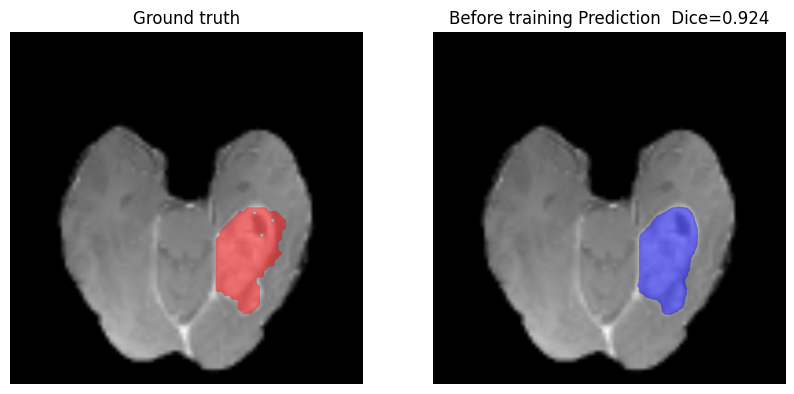

In [ ]:
def predict_and_plot(model, dataset, idx, device, title=''):
    model.eval()
    image, mask, box, pid = dataset[idx]
    image = image.to(device).float()
    img = (image - image.min()) / (image.max() - image.min() + 1e-8)   # [0,1], no preprocess
    inp = img.unsqueeze(0)
    with torch.no_grad():
        emb = model.image_encoder(inp)
        sparse_emb, dense_emb = model.prompt_encoder(
            points=None, boxes= , masks=None) ##FILL )
        low_res, _ = model.mask_decoder(
            image_embeddings=emb, image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=, dense_prompt_embeddings=,
            multimask_output=False) #FILL
        up = F.interpolate(low_res, size=mask.shape[-2:], mode='bilinear', align_corners=False)
        pred = (torch.sigmoid(up) > 0.5).cpu().numpy()[0, 0]

    gt = mask.numpy()[0]
    base = img.mean(0).cpu().numpy()
    d = dice_score(pred, gt)
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(base, cmap='gray')
    axs[0].imshow(np.ma.masked_where(gt == 0, gt), alpha=0.5, cmap='autumn')
    axs[0].set_title('Ground truth'); axs[0].axis('off')
    axs[1].imshow(base, cmap='gray')
    axs[1].imshow(np.ma.masked_where(pred == 0, pred), alpha=0.5, cmap='winter')
    axs[1].set_title(f'{title} Prediction  Dice={d:.3f}'); axs[1].axis('off')
    plt.show()
    return d

_ = predict_and_plot(finetune_model, val_dataset, 1, device, title='Before training')


### 6.6. Train for several epochs and track the curves


In [ ]:
N_EPOCHS = 2   # increase if you have time / GPU; even 2-3 epochs show clear learning
history = []
best_val = -1

for epoch in range(N_EPOCHS):
    metrics = single_epoch(epoch, finetune_model, train_loader, val_loader, optimizer, criterion, device)
    history.append(metrics)
    print(f"Epoch {epoch}: "
          f"train loss {metrics['train_loss']:.4f} / dice {metrics['train_dice']:.4f} | "
          f"val loss {metrics['val_loss']:.4f} / dice {metrics['val_dice']:.4f}")
    if metrics['val_dice'] > best_val:
        best_val = metrics['val_dice']
        save_checkpoint({'epoch': epoch, 'val_loss': metrics['val_loss'],
                         'state_dict': finetune_model.mask_decoder.state_dict()},
                        './checkpoints')
        print(f"  -> new best val Dice {best_val:.4f}, checkpoint saved.")

  0%|          | 0/1697 [00:00<?, ?it/s]

KeyboardInterrupt: 

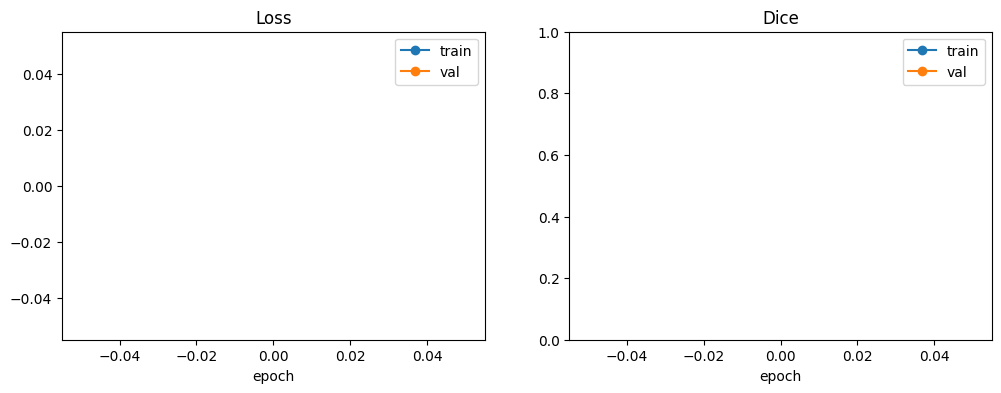

In [ ]:
ep = range(len(history))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, [h['train_loss'] for h in history], '-o', label='train')
ax[0].plot(ep, [h['val_loss']   for h in history], '-o', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, [h['train_dice'] for h in history], '-o', label='train')
ax[1].plot(ep, [h['val_dice']   for h in history], '-o', label='val')
ax[1].set_title('Dice'); ax[1].set_xlabel('epoch'); ax[1].set_ylim(0, 1); ax[1].legend()
plt.show()

### 6.7. Qualitative check **after** training


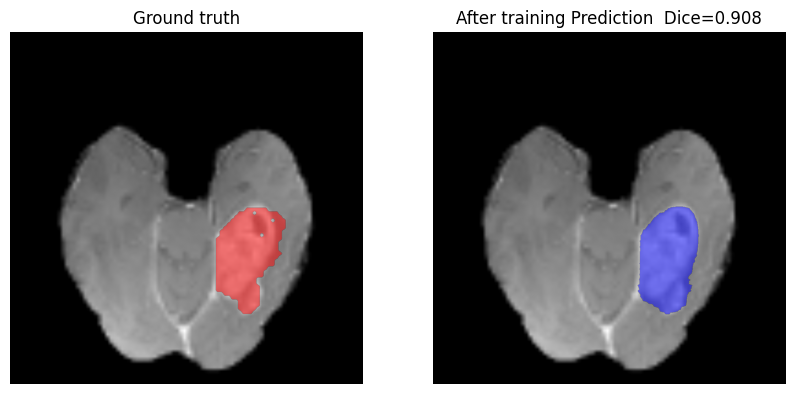

In [ ]:
_ = predict_and_plot(finetune_model, val_dataset, 1, device, title='After training')

### 6.8. Final test-set evaluation

Report mean Dice on the held-out **test** set with the finetuned model.


In [ ]:
def evaluate_dataset(model, loader, device, max_batches=None):
    model.eval()
    dices = []
    for i, batch in enumerate(tqdm(loader)):
        if max_batches and i >= max_batches:
            break
        _, d = single_step(batch, model, None, criterion, device, 'val')
        dices.append(d)
    return float(np.mean(dices)), float(np.std(dices))

# Finetuned SAM decoder
test_mean, test_std = evaluate_dataset(finetune_model, test_loader, device, max_batches=60)
print(f"Finetuned model    — test Dice: {test_mean:.3f} ± {test_std:.3f}")

# Zero-shot (non-finetuned) SAM, same box-prompt path, same test batches
zs_mean, zs_std = evaluate_dataset(model, test_loader, device, max_batches=60)
print(f"Zero-shot model    — test Dice: {zs_mean:.3f} ± {zs_std:.3f}")

# Comparison
delta = test_mean - zs_mean
print(f"\nFinetuning gain    — Δ test Dice: {delta:+.3f} "
      f"({100*delta/max(zs_mean, 1e-8):+.1f}% relative)")

  0%|          | 0/1155 [00:00<?, ?it/s]

Finetuned model    — test Dice: 0.682 ± 0.211


  0%|          | 0/1155 [00:00<?, ?it/s]

Zero-shot model    — test Dice: 0.650 ± 0.218

Finetuning gain    — Δ test Dice: +0.033 (+5.0% relative)


## 7. Bonus — a U-Net baseline

A common question is whether the foundation model is worth it here. The classic
medical-imaging baseline is the U-Net. We train a small U-Net on the same
3-channel slices and compare. The U-Net is not promptable: it segments the whole
image directly, which removes the need for a prompt at test time but also removes
interactive correction.

### 7.1. A compact U-Net

> **FILL.** Complete the U-Net decoder: each step upsamples and concatenates with the matching encoder feature map (skip connection) before the conv block.


In [ ]:
import torch.nn as nn

def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.e1 = conv_block(in_ch, base)
        self.e2 = conv_block(base, base * 2)
        self.e3 = conv_block(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)
        self.b = conv_block(base * 4, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.d3 = conv_block(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.d2 = conv_block(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.d1 = conv_block(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        b = self.b(self.pool(e3))
        # FILL: decoder with skip connections. Upsample, concat with the matching
        # encoder map along the channel dim (dim=1), then apply the conv block.
        d3 = self.d3(torch.cat([self.up3(b),  ...], 1))   # FILL  (hint: e3)
        d2 = self.d2(torch.cat([self.up2(d3), ...], 1))   # FILL  (hint: e2)
        d1 = self.d1(torch.cat([self.up1(d2), ...], 1))   # FILL  (hint: e1)
        return self.out(d1)

unet = UNet(in_ch=3).to(device)
print(f"U-Net trainable parameters: {sum(p.numel() for p in unet.parameters()):,}")

### 7.2. A lightweight loader at native resolution

The U-Net does not need 1024×1024; we train it on the native 96×96 slices, which is far faster. We reuse the IDs but read the slices directly.


In [ ]:
class UNetDataset(torch.utils.data.Dataset):
    def __init__(self, ids, data_path, modalities=['t2', 't1ce', 'flair']):
        self.ids = ids; self.data_path = data_path; self.modalities = modalities
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, idx):
        patient, z = self.ids[idx]
        p = os.path.join(self.data_path, patient)
        irm = np.stack([load_sitk(os.path.join(p, f"{patient}_{m}_z_{z}.nii.gz"))
                        for m in self.modalities], 0).astype(np.float32)
        irm = (irm - irm.min()) / (irm.max() - irm.min() + 1e-8)
        seg = load_sitk(os.path.join(p, f"{patient}_seg_z_{z}.nii.gz")).astype(np.float32)
        seg = (seg > 0).astype(np.float32)[None]
        return torch.tensor(irm), torch.tensor(seg)

unet_train = torch.utils.data.DataLoader(UNetDataset(train_IDs, data_path), batch_size=16, shuffle=True, drop_last=True)
unet_val   = torch.utils.data.DataLoader(UNetDataset(val_IDs,   data_path), batch_size=16, shuffle=False)


### 7.3. Train the U-Net


In [ ]:
unet_opt = torch.optim.AdamW(unet.parameters(), lr=1e-3, weight_decay=1e-4)
unet_hist = []

for epoch in range(8):
    unet.train(); tr = []
    for x, y in tqdm(unet_train, leave=False, desc=f'U-Net train e{epoch}'):
        x, y = x.to(device), y.to(device)
        logits = #FILL forward pass
        loss = #FILL Dice loss
        unet_opt.zero_grad(); loss.backward(); unet_opt.step()
        tr.append(loss.item())
    unet.eval(); ds = []
    with torch.no_grad():
        for x, y in unet_val:
            x, y = x.to(device), y.to(device)
            pred = (torch.sigmoid(unet(x)) > 0.5).float()
            inter = (pred * y).sum([1,2,3]); union = pred.sum([1,2,3]) + y.sum([1,2,3])
            ds.extend(((2*inter+1e-6)/(union+1e-6)).cpu().numpy().tolist())
    unet_hist.append(np.mean(ds))
    print(f"epoch {epoch}: train loss {np.mean(tr):.4f} | val Dice {np.mean(ds):.4f}")

U-Net train e0:   0%|          | 0/424 [00:00<?, ?it/s]

epoch 0: train loss 0.6525 | val Dice 0.8068


U-Net train e1:   0%|          | 0/424 [00:00<?, ?it/s]

epoch 1: train loss 0.2461 | val Dice 0.7765


U-Net train e2:   0%|          | 0/424 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 7bis. Test-set evaluation of the 2D methods

The sections above reported validation numbers or single-slice demos. Here we
report test-set Dice for the three 2D methods with the same metric definition on
the same held-out patients, so the numbers are comparable. The 3D method
(MedSAM2) is evaluated in Section 8 and everything is gathered in
the final comparison.

| # | Method | Granularity | Prompt | Trainable params |
|---|--------|-------------|--------|------------------|
| 1 | SAM zero-shot (box) | 2D slice | GT box | 0 |
| 2 | SAM full-finetuned decoder | 2D slice | GT box | ~4M (decoder) |
| 3 | U-Net | 2D slice | none | ~0.5M |

For the promptable models we score each tumour slice in the test-ID list, since a
box only makes sense where there is a tumour.


In [ ]:
from collections import defaultdict

@torch.no_grad()
def eval_sam_2d_testset(sam_model, ids, device, tag='SAM'):
    """Per-slice hard Dice on the test IDs using the MedSAM-style box path.
    Returns (per_slice_dice[list], per_patient_dice[dict])."""
    sam_model.eval()
    per_slice, per_patient = [], defaultdict(list)
    for patient, z in tqdm(ids, desc=f'{tag} (2D test)', leave=False):
        p = os.path.join(data_path, patient)
        flair = load_sitk(os.path.join(p, f"{patient}_flair_z_{z}.nii.gz"))
        seg   = (load_sitk(os.path.join(p, f"{patient}_seg_z_{z}.nii.gz")) > 0).astype(np.uint8)
        box = mask_to_box(seg, perturbation=0)
        if box is None:
            continue
        pred = sam_box_inference(sam_model, flair, box, device)
        d = dice_score(pred, seg)
        per_slice.append(d); per_patient[patient].append(d)
    return per_slice, per_patient

@torch.no_grad()
def eval_unet_2d_testset(unet_model, ids, device):
    """Per-slice hard Dice for the (non-promptable) U-Net at native resolution."""
    unet_model.eval()
    per_slice, per_patient = [], defaultdict(list)
    for patient, z in tqdm(ids, desc='U-Net (2D test)', leave=False):
        p = os.path.join(data_path, patient)
        irm = np.stack([load_sitk(os.path.join(p, f"{patient}_{m}_z_{z}.nii.gz"))
                        for m in ['t2', 't1ce', 'flair']], 0).astype(np.float32)
        irm = (irm - irm.min()) / (irm.max() - irm.min() + 1e-8)
        seg = (load_sitk(os.path.join(p, f"{patient}_seg_z_{z}.nii.gz")) > 0).astype(np.uint8)
        x = torch.tensor(irm)[None].to(device)
        pred = (torch.sigmoid(unet_model(x)) > 0.5).float().cpu().numpy()[0, 0]
        d = dice_score(pred, seg)
        per_slice.append(d); per_patient[patient].append(d)
    return per_slice, per_patient

# Cap the number of scored slices for speed; raise/remove for a full run.
MAX_TEST_SLICES = 100
test_ids_eval = test_IDs[:MAX_TEST_SLICES]
print(f"Scoring {len(test_ids_eval)} test slices per 2D method "
      f"(of {len(test_IDs)} available).")

samzs_slice,  samzs_pat  = eval_sam_2d_testset(model,          test_ids_eval, device, tag='SAM-zeroshot')
samft_slice,  samft_pat  = eval_sam_2d_testset(finetune_model, test_ids_eval, device, tag='SAM-finetuned')
unet_slice,   unet_pat   = eval_unet_2d_testset(unet,          test_ids_eval, device)

def summ(a): a = np.asarray(a); return (a.mean(), a.std(), len(a))
for name, arr in [('SAM zero-shot (box)', samzs_slice),
                  ('SAM full-finetuned',  samft_slice),
                  ('U-Net',               unet_slice)]:
    m, s, n = summ(arr)
    print(f"{name:24s}  test Dice {m:.3f} +/- {s:.3f}  (n={n} slices)")


Scoring 100 test slices per 2D method (of 1155 available).


SAM-zeroshot (2D test):   0%|          | 0/100 [00:00<?, ?it/s]

SAM-finetuned (2D test):   0%|          | 0/100 [00:00<?, ?it/s]

U-Net (2D test):   0%|          | 0/100 [00:00<?, ?it/s]

SAM zero-shot (box)       test Dice 0.735 +/- 0.239  (n=100 slices)
SAM full-finetuned        test Dice 0.754 +/- 0.196  (n=100 slices)
U-Net                     test Dice 0.792 +/- 0.176  (n=100 slices)


## 8. MedSAM2: 3D volumetric segmentation from one box prompt

So far every model worked slice by slice. MedSAM2 (Ma et al., 2025) is built on
SAM2 (a video model) and segments a whole 3D volume from a single box prompt on
one slice, propagating the mask through the volume with a learned memory-attention
module, forward and backward from the prompted slice.

This section follows the official MedSAM2 3D-inference recipe (the
`build_sam2_video_predictor_npz` API): preprocess the volume to uint8 `[0, 255]`,
resize slices to 512x512, ImageNet-normalise, prompt the centre tumour slice with
a box, then propagate forward and backward.

Needs a GPU and downloads the SAM2 fork plus a ~150 MB checkpoint.


### 8.1. Install MedSAM2 and download the checkpoint


In [ ]:
import os
if not os.path.exists('MedSAM2'):
    os.system('git clone -q https://github.com/bowang-lab/MedSAM2.git')
!pip install -q -e MedSAM2 2>/dev/null
!pip install -q huggingface_hub hydra-core iopath

from huggingface_hub import hf_hub_download
os.makedirs('checkpoints', exist_ok=True)
# MedSAM2_2411.pt is the base 3D/video checkpoint used in the BraTS tutorial.
ckpt = hf_hub_download(repo_id='wanglab/MedSAM2', filename='MedSAM2_2411.pt',
                       local_dir='checkpoints', local_dir_use_symlinks=False)
print(f"MedSAM2 checkpoint: {os.path.getsize(ckpt)/1e6:.1f} MB at {ckpt}")
assert os.path.getsize(ckpt) > 50e6, "MedSAM2 checkpoint download failed."


'[Errno 101] Network is unreachable' thrown while requesting HEAD https://huggingface.co/wanglab/MedSAM2/resolve/main/MedSAM2_2411.pt
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

### 8.2. Build the MedSAM2 video predictor

`build_sam2_video_predictor_npz` (from the MedSAM2 fork) loads the Hiera encoder + memory attention + mask decoder. Its `init_state` accepts a preloaded `(D, 3, 512, 512)` tensor directly.


In [ ]:
import sys, torch, numpy as np
sys.path.append('MedSAM2')
from sam2.build_sam import build_sam2_video_predictor_npz

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cfg = 'configs/sam2.1_hiera_t512.yaml'   # tiny-512 config that matches MedSAM2_2411.pt
predictor2 = build_sam2_video_predictor_npz(model_cfg, "checkpoints/MedSAM2_2411.pt")
predictor2 = predictor2.to(device)
predictor2.eval()
print("MedSAM2 video predictor ready on", device)


MedSAM2 video predictor ready on cuda


### 8.3. Helper functions (from the official BraTS MedSAM2 tutorial)

`preprocess_volume` normalises to uint8 `[0,255]`; `resize_to_512` resizes each slice; `getLargestCC` keeps the biggest connected component to clean up stray predictions; `get_bbox_from_mask` derives the box prompt from the GT on the prompt slice.


In [ ]:
from PIL import Image
from skimage import measure

def getLargestCC(segmentation):
    labels = measure.label(segmentation)
    if labels.max() == 0:
        return segmentation.astype(np.uint8)
    largest = labels == (np.argmax(np.bincount(labels.flat)[1:]) + 1)
    return largest.astype(np.uint8)

def preprocess_volume_255(volume_array):
    v = volume_array.astype(np.float32)
    v = (v - v.min()) / (v.max() - v.min() + 1e-8) * 255.0
    return v.astype(np.uint8)

def resize_to_512(array_3d):
    out = np.zeros((array_3d.shape[0], 512, 512), dtype=np.uint8)
    for i in range(array_3d.shape[0]):
        out[i] = np.array(Image.fromarray(array_3d[i]).resize((512, 512)))
    return out

def get_bbox_from_mask(mask_slice):
    ys, xs = np.where(mask_slice > 0)
    if len(xs) == 0:
        return np.array([0, 0, 512, 512])
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()])

def dice_np(pred, true):
    pred, true = pred.astype(bool), true.astype(bool)
    inter = np.logical_and(pred, true).sum()
    return 2. * inter / (pred.sum() + true.sum() + 1e-8)

def iou_np(pred, true):
    pred, true = pred.astype(bool), true.astype(bool)
    inter = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()
    return inter / (union + 1e-8)


### 8.4. One-prompt 3D inference (forward + backward propagation)

The volume is stacked to 3-channel, ImageNet-normalised, and passed to `init_state`. We add the box on the center tumour slice with `add_new_points_or_box`, then run `propagate_in_video` forward and again with `reverse=True`.


In [ ]:
def one_prompt_inference(volume_255, prompt_slice_idx, bbox, predictor, device):
    """MedSAM2 one-prompt 3D inference. volume_255: (D,H,W) uint8. Returns (D,512,512) uint8."""
    volume_resized = resize_to_512(volume_255)                       # (D,512,512)
    volume_rgb = np.stack([volume_resized] * 3, axis=1) / 255.0      # (D,3,512,512)
    img_mean = np.array([0.485, 0.456, 0.406])[:, None, None]
    img_std  = np.array([0.229, 0.224, 0.225])[:, None, None]
    volume_rgb = (volume_rgb - img_mean) / img_std
    volume_tensor = torch.from_numpy(volume_rgb).float().to(device)

    segs_3D = np.zeros(volume_resized.shape, dtype=np.uint8)
    with torch.inference_mode():
        state = predictor.init_state(volume_tensor, 512, 512)

        predictor.add_new_points_or_box(state, prompt_slice_idx, obj_id=1, box=bbox)
        for idx, _, logits in predictor.propagate_in_video(state):
            segs_3D[idx, (logits[0] > 0.0).cpu().numpy()[0]] = 1

        predictor.add_new_points_or_box(state, prompt_slice_idx, obj_id=1, box=bbox)
        for idx, _, logits in predictor.propagate_in_video(state, reverse=True):
            segs_3D[idx, (logits[0] > 0.0).cpu().numpy()[0]] = 1

    return getLargestCC(segs_3D) if segs_3D.max() > 0 else segs_3D


### 8.5. Run on a BraTS volume


In [ ]:
# Reuse the volume loaders (defined in Section 5/earlier helpers).
def load_volume(patient, modality='flair', n_slices=78):
    vol = []
    for z in range(n_slices):
        fp = os.path.join(data_path, patient, f"{patient}_{modality}_z_{z}.nii.gz")
        if not os.path.exists(fp):
            break
        vol.append(load_sitk(fp))
    return np.stack(vol, 0).astype(np.float32)

def load_seg_volume(patient, n_slices=78):
    vol = []
    for z in range(n_slices):
        fp = os.path.join(data_path, patient, f"{patient}_seg_z_{z}.nii.gz")
        if not os.path.exists(fp):
            break
        vol.append((load_sitk(fp) > 0).astype(np.uint8))
    return np.stack(vol, 0)

prop_patient = test_split[3] if len(test_split) else 'BraTS19_CBICA_ANP_1'
img_vol = load_volume(prop_patient, 't1ce')
gt_vol  = load_seg_volume(prop_patient)

volume_255 = preprocess_volume_255(img_vol)
gt_512 = resize_to_512(gt_vol)

# Center tumour slice + box prompt from GT there.
tumour_slices = np.where(gt_512.sum((1, 2)) > 0)[0]
center_slice_idx = int(tumour_slices[len(tumour_slices) // 2]) if len(tumour_slices) else img_vol.shape[0] // 2
bbox = get_bbox_from_mask(gt_512[center_slice_idx])
print(f"{prop_patient}: prompt slice {center_slice_idx}, box {bbox}")

segmentation = one_prompt_inference(volume_255, center_slice_idx, bbox, predictor2, device)

dice = dice_np(segmentation, gt_512)
iou  = iou_np(segmentation, gt_512)
print(f"MedSAM2 one-prompt  Dice: {dice:.4f} | IoU: {iou:.4f}")


BraTS19_TCIA10_442_1: prompt slice 32, box [ 75 171 207 362]


/lustre/fsn1/projects/rech/ywz/ucy78gw/GE_TP/MedSAM2/sam2/sam2_video_predictor_npz.py:965: UserWarning: Python version mismatch: module was compiled for Python 3.12, but the interpreter version is incompatible: 3.10.20 (main, Jun 11 2026, 15:17:37) [GCC 14.3.0].

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 46/46 [00:00<00:00, 72.18it/s]
/lustre/fsn1/projects/rech/ywz/ucy78gw/histaug_env/ge_tp/lib/python3.10/site-packages/torch/utils/_contextlib.py:124: UserWarning: You are adding a box after tracking starts. SAM 2 may not always be able to incorporate a box prompt for *refinement*. If you intend to use box prompt as an *initial* input before tracking, plea

MedSAM2 one-prompt  Dice: 0.8714 | IoU: 0.7721


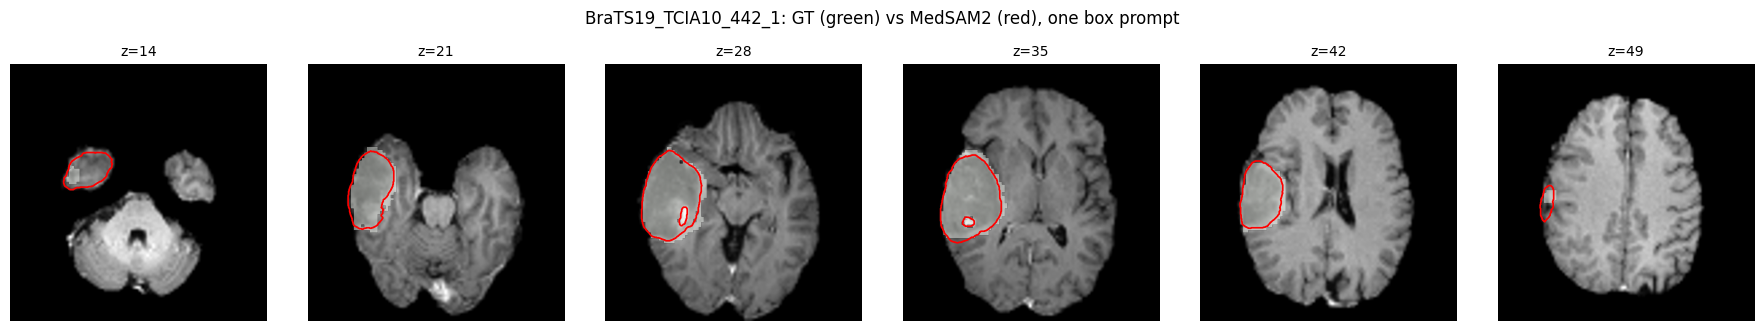

In [ ]:

volume_512 = resize_to_512(volume_255)
show_zs = np.linspace(tumour_slices.min(), tumour_slices.max(), 6).astype(int)

fig, axs = plt.subplots(1, len(show_zs), figsize=(3 * len(show_zs), 3.2))
for ax, z in zip(axs, show_zs):
    ax.imshow(volume_512[z], cmap='gray')
    ax.imshow(np.ma.masked_where(gt_512[z] == 0, gt_512[z]), alpha=0.45, cmap='Greens')
    ax.contour(segmentation[z], levels=[0.5], colors='red', linewidths=1.2)
    ax.set_title(f"z={z}" + ("  \u2605box" if z == center_slice_idx else ""), fontsize=10)
    ax.axis('off')
plt.suptitle(f"{prop_patient}: GT (green) vs MedSAM2 (red), one box prompt", y=1.02)
plt.tight_layout(); plt.show()


### 8.6. MedSAM2: 3D evaluation on 20-slice sub-volumes

We now evaluate MedSAM2 quantitatively rather than on a single volume. For each
test patient we take the T1ce volume, crop a 20-slice window centred on the
tumour, place one box prompt on the centre slice, and propagate through the
window. Restricting to 20 slices keeps every volume the same depth and keeps the
run cheap while still exercising forward and backward propagation. We report one
Dice per volume.

> **FILL.** In `medsam2_eval_volume`, derive the box prompt from the GT on the centre slice with `get_bbox_from_mask`. The forward/backward propagation is done inside `one_prompt_inference`, which is already provided.


In [ ]:
# 3D evaluation of MedSAM2 on fixed-depth 20-slice windows.
N_SLICES_3D   = 50               # depth of the evaluated sub-volume
N_TEST_VOLS   = 20                # number of test patients to score (raise for a full run)

def tumour_window(gt_vol, depth):
    """Return (z0, z1) slice range of length `depth` centred on the tumour."""
    zt = np.where(gt_vol.sum((1, 2)) > 0)[0]
    if len(zt) == 0:
        c = gt_vol.shape[0] // 2
    else:
        c = int((zt.min() + zt.max()) // 2)
    z0 = max(0, c - depth // 2)
    z1 = min(gt_vol.shape[0], z0 + depth)
    z0 = max(0, z1 - depth)
    return z0, z1

def medsam2_eval_volume(patient, predictor, device, depth=N_SLICES_3D):
    """One box prompt on the centre slice, propagate through a `depth`-slice window.
    Returns (dice, iou) against the ground truth on that window, or None if no tumour."""
    img_vol = load_volume(patient, 't1ce')
    gt_vol  = load_seg_volume(patient)
    z0, z1 = tumour_window(gt_vol, depth)

    img_win = img_vol[z0:z1]
    gt_win  = gt_vol[z0:z1]
    if gt_win.sum() == 0:
        return None

    vol_255 = preprocess_volume_255(img_win)
    gt_512  = resize_to_512(gt_win)

    tsl = np.where(gt_512.sum((1, 2)) > 0)[0]
    centre = int(tsl[len(tsl) // 2])
    # FILL: box prompt from the ground-truth mask on the centre slice.
    bbox = ...   # FILL  

    seg = one_prompt_inference(vol_255, centre, bbox, predictor, device)
    return dice_np(seg, gt_512), iou_np(seg, gt_512)

eval_patients = [p for p in test_split][:N_TEST_VOLS]
zs_dice, zs_iou = [], []
for p in tqdm(eval_patients, desc='MedSAM2 zero-shot (3D, 50 slices)'):
    r = medsam2_eval_volume(p, predictor2, device)
    if r is not None:
        zs_dice.append(r[0]); zs_iou.append(r[1])

print(f"MedSAM2 zero-shot on {len(zs_dice)} volumes "
      f"({N_SLICES_3D}-slice windows):")
print(f"  Dice: {np.mean(zs_dice):.3f} +/- {np.std(zs_dice):.3f}")
print(f"  IoU : {np.mean(zs_iou):.3f} +/- {np.std(zs_iou):.3f}")

## 8bis. Final comparison across all methods

We gather the three 2D methods and the MedSAM2 3D zero-shot result into one table
and bar chart. The 2D and 3D numbers measure different tasks (per-slice vs
whole-volume), so we group them by colour rather than reading them as a single
ranking.

Method                            Test Dice     95% CI (bootstrap)     n
------------------------------------------------------------------------
SAM zero-shot (box, 2D)               0.735         [0.682, 0.778]   100
SAM full-FT (decoder, 2D)             0.754         [0.710, 0.788]   100
U-Net (no prompt, 2D)                 0.792         [0.750, 0.822]   100
MedSAM2 zero-shot (1 box, 3D)         0.615         [0.537, 0.695]    20


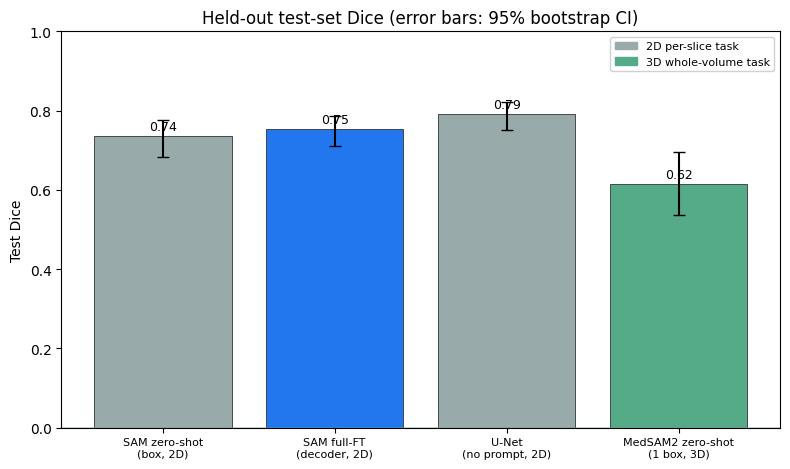

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import bootstrap

def boot_ci(a, n_resamples=10000, confidence=0.95):
    """Bootstrap CI of the mean. Returns (low, high). Falls back gracefully if n<2."""
    # TO FILL
    return float(res.confidence_interval.low), float(res.confidence_interval.high)

results = {
    'SAM zero-shot\n(box, 2D)':       dict(arr=samzs_slice, family='2D'),
    'SAM full-FT\n(decoder, 2D)':     dict(arr=samft_slice, family='2D'),
    'U-Net\n(no prompt, 2D)':         dict(arr=unet_slice,  family='2D'),
    'MedSAM2 zero-shot\n(1 box, 3D)': dict(arr=zs_dice,     family='3D'),
}

for r in results.values():
    a = np.asarray(r['arr'], dtype=float)
    r['dice'] = float(a.mean())
    r['lo'], r['hi'] = boot_ci(a)

print(f"{'Method':32s} {'Test Dice':>10s} {'95% CI (bootstrap)':>22s} {'n':>5s}")
print('-' * 72)
for name, r in results.items():
    flat = name.replace(chr(10), ' ')
    ci_str = f"[{r['lo']:.3f}, {r['hi']:.3f}]"
    print(f"{flat:32s} {r['dice']:>10.3f} {ci_str:>22s} {len(r['arr']):>5d}")

fig, ax = plt.subplots(figsize=(8, 4.8))
names  = list(results.keys())
vals   = [results[n]['dice'] for n in names]

lower  = [results[n]['dice'] - results[n]['lo'] for n in names]
upper  = [results[n]['hi']  - results[n]['dice'] for n in names]
yerr   = np.clip(np.array([lower, upper]), 0, None)

colors = ['#9aa' if results[n]['family'] == '2D' else '#5a8' for n in names]
colors[1] = '#27e'
bars = ax.bar(names, vals, yerr=yerr, capsize=4,
              color=colors, edgecolor='#333', linewidth=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f'{v:.2f}', ha='center', fontsize=9)
ax.set_ylabel('Test Dice'); ax.set_ylim(0, 1)
ax.set_title('Held-out test-set Dice (error bars: 95% bootstrap CI)')
ax.axhspan(0, 0, color='#9aa', label='2D per-slice task')
ax.axhspan(0, 0, color='#5a8', label='3D whole-volume task')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

## 9. Report generation: LoRA-finetuning a light vision-language model

Every model so far answered *where* is the tumour, given a prompt. Vision-language
models (VLMs) answer a different question: given a scan, produce free-text output.
Radiology report generation (RRG) is the dominant task of this family, usually
benchmarked on chest-X-ray datasets such as MIMIC-CXR.

Most captioning VLMs share one skeleton: a vision encoder turns the image into
embeddings, and a text decoder generates tokens conditioned on those embeddings
through cross-attention. BLIP is a small, open encoder-decoder model of this kind
(a ViT image encoder feeding a Transformer text decoder), light enough for a free
Colab GPU, which is why we use it rather than a large medical VLM such as
MedGemma.

Off the shelf, BLIP was trained on natural images and web captions, so its
description of an MRI slice is fluent but clinically meaningless. In this section
we close that gap the parameter-efficient way: we build a small supervised
image to text dataset from BraTS, then finetune BLIP with LoRA (Low-Rank
Adaptation), which freezes the base weights and trains only tiny low-rank updates
inside the decoder's attention. This is the generative-model analogue of the
decoder-only finetuning we did for SAM in Section 6.

In [ ]:
# Light VLM stack. BLIP base captioning (~0.99B params) + PEFT for LoRA.
!pip install -q "transformers>=4.40" "peft>=0.11" pillow

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from peft import LoraConfig, get_peft_model
from PIL import Image
import numpy as np, torch

vlm_device = 'cuda' if torch.cuda.is_available() else 'cpu'
blip_id = 'Salesforce/blip-image-captioning-base'
blip_processor = BlipProcessor.from_pretrained(blip_id)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_id).to(vlm_device)
print('Loaded', blip_id, 'on', vlm_device)
print(f'Base parameters: {sum(p.numel() for p in blip_model.parameters()):,}')

### 9.1. Build a supervised image to text dataset from BraTS

We do not have real radiology reports for BraTS, so we synthesise a short,
structured caption for each slice directly from its ground-truth mask: whether a
tumour is present, its rough size (fraction of the slice), and its location
(left/right, upper/lower). This is a deliberately simple label, but it is enough
to teach the supervised captioning setup and to make the domain gap visible after
finetuning.

Each training example is a `(RGB slice, caption)` pair. We reuse the slice index
lists `train_IDs` / `val_IDs` (each a list of `(patient, z)`), `data_path`, and
`load_sitk` from earlier sections.

In [ ]:
def slice_to_rgb(arr, size=384):
    """2D grayscale slice -> 384x384 uint8 RGB PIL image (BLIP's input size)."""
    a = arr.astype(np.float32)
    a = (a - a.min()) / (a.max() - a.min() + 1e-8) * 255.0
    rgb = np.stack([a.astype(np.uint8)] * 3, axis=-1)
    return Image.fromarray(rgb).resize((size, size))

def mask_to_caption(mask):
    """Structured caption derived from a binary tumour mask."""
    h, w = mask.shape
    area = mask.sum()
    if area == 0:
        return "brain mri slice with no visible tumor"
    frac = area / (h * w)
    size = "small" if frac < 0.02 else "medium" if frac < 0.06 else "large"
    ys, xs = np.where(mask > 0)
    cy, cx = ys.mean(), xs.mean()
    horiz = "left" if cx < w / 2 else "right"
    vert  = "upper" if cy < h / 2 else "lower"
    return f"brain mri slice with a {size} tumor in the {vert} {horiz} region"

def build_caption_dataset(id_list, modality='flair', max_items=300):
    """Return a list of (PIL image, caption) pairs."""
    items = []
    for patient, z in id_list[:max_items]:
        img_fp = os.path.join(data_path, patient, f"{patient}_{modality}_z_{z}.nii.gz")
        seg_fp = os.path.join(data_path, patient, f"{patient}_seg_z_{z}.nii.gz")
        if not (os.path.exists(img_fp) and os.path.exists(seg_fp)):
            continue
        img = slice_to_rgb(load_sitk(img_fp))
        mask = (load_sitk(seg_fp) > 0).astype(np.uint8)
        items.append((img, mask_to_caption(mask)))
    return items

train_pairs = build_caption_dataset(train_IDs, max_items=300)
val_pairs   = build_caption_dataset(val_IDs,   max_items=60)
print(f"train pairs: {len(train_pairs)} | val pairs: {len(val_pairs)}")
print("example caption:", train_pairs[0][1])

### 9.2. Baseline: BLIP before finetuning

First, the off-the-shelf output on a validation slice. Expect something generic
and non-medical, which is the whole point: a general-domain model has never seen
a labelled brain MRI.

In [ ]:
@torch.no_grad()
def blip_caption(model, pil_img, prompt=None, max_new_tokens=30):
    model.eval()
    if prompt is None:
        inputs = blip_processor(pil_img, return_tensors='pt').to(vlm_device)
    else:
        inputs = blip_processor(pil_img, prompt, return_tensors='pt').to(vlm_device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return blip_processor.decode(out[0], skip_special_tokens=True)

demo_img, demo_ref = val_pairs[0]
print("Reference     :", demo_ref)
print("BLIP (before) :", blip_caption(blip_model, demo_img))
demo_img

### 9.3. Attach LoRA adapters to the decoder attention

LoRA replaces a weight update \(\Delta W\) with a low-rank product \(BA\)
(rank \(r \ll d\)): the base weight is frozen and only \(A\) and \(B\) are
trained. For BLIP-base the decoder self-attention projections are named
`self.query`, `self.key`, `self.value`; targeting the query and value projections
is the standard, stable choice (targeting `q_proj`/`k_proj`, as one would for some
LLMs, does not match BLIP's module names and fails). This trains well under 1% of
the model.

> **FILL.** Complete the `LoraConfig`: set the rank `r`, `lora_alpha`, and the
> `target_modules` list, then wrap the model with `get_peft_model`.

In [ ]:
# FILL: LoRA rank (small, e.g. 8) and scaling alpha (e.g. 16 or 32).
lora_config = LoraConfig(
    r=...,                       # FILL  
    lora_alpha=...,              # FILL  
    lora_dropout=0.05,
    bias="none",
    # FILL: which linear layers to adapt (BLIP decoder attention query + value).
    target_modules=...,          # FILL  
)

# FILL: wrap the base model so only the LoRA params are trainable.
blip_model = ...                 # FILL  
blip_model.print_trainable_parameters()

### 9.4. Finetune with LoRA

The captioning loss is the language-model cross-entropy on the target tokens.
`BlipForConditionalGeneration` computes it for us when we pass `labels`: it shifts
them internally and returns `outputs.loss`. A few hundred steps on this tiny
dataset is enough to see the style shift.

> **FILL.** Inside the loop, call the model with `pixel_values`, `input_ids`, and
> `labels`, and read `outputs.loss`.

In [ ]:
from torch.utils.data import DataLoader

def collate(batch):
    imgs = [b[0] for b in batch]
    caps = [b[1] for b in batch]
    enc = blip_processor(images=imgs, text=caps, padding=True,
                         return_tensors='pt')
    return enc

train_loader_vlm = DataLoader(train_pairs, batch_size=8, shuffle=True, collate_fn=collate)

optimizer_vlm = torch.optim.AdamW(
    [p for p in blip_model.parameters() if p.requires_grad], lr=5e-4)

N_STEPS = 150
blip_model.train()
step = 0
from tqdm.auto import tqdm
pbar = tqdm(total=N_STEPS, desc='BLIP LoRA finetune')
while step < N_STEPS:
    for enc in train_loader_vlm:
        pixel_values = enc['pixel_values'].to(vlm_device)
        input_ids    = enc['input_ids'].to(vlm_device)
        # FILL: forward pass. Pass pixel_values, input_ids, and labels=input_ids.
        outputs = ...            # FILL
        # FILL: read the language-model loss from the outputs.
        loss = ...               # FILL
        optimizer_vlm.zero_grad()
        loss.backward()
        optimizer_vlm.step()
        step += 1; pbar.update(1); pbar.set_postfix(loss=f"{loss.item():.3f}")
        if step >= N_STEPS:
            break
pbar.close()

### 9.5. After finetuning, and a quick quantitative check

Same slice as before, now with the LoRA-adapted decoder. The output should now
follow the structured "brain mri slice with a ... tumor in the ..." style. We
also compute a token-overlap score (BLEU) over the validation set as a coarse
before/after signal.

In [ ]:
print("Reference    :", demo_ref)
print("BLIP (after) :", blip_caption(blip_model, demo_img))

# Coarse token-overlap metric (BLEU-ish) before vs after, on a val subset.
def word_f1(pred, ref):
    p, r = set(pred.lower().split()), set(ref.lower().split())
    if not p or not r:
        return 0.0
    tp = len(p & r)
    prec, rec = tp / len(p), tp / len(r)
    return 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)

scores = [word_f1(blip_caption(blip_model, im), ref) for im, ref in val_pairs[:40]]
print(f"Mean word-overlap F1 (after, n={len(scores)}): {np.mean(scores):.3f}")

## 10. Wrap-up, limitations and extensions

What we did:
1. Inspected SAM's promptable architecture and the encoder/decoder parameter
   asymmetry.
2. Built a slice-wise BraTS pipeline that emits box prompts from masks.
3. Ran SAM zero-shot with point and box prompts, and saw that boxes are more
   robust.
4. Fully finetuned SAM's mask decoder using box prompts, tracked Dice, and saved
   checkpoints.
5. Benchmarked against a U-Net baseline.
6. Ran MedSAM2 for 3D one-prompt segmentation with forward and backward memory
   propagation.
7. Evaluated every method on the held-out test set with a common metric and a
   consolidated table and figure, including a 3D evaluation on 20-slice
   sub-volumes.

Limitations:
- 2D vs 3D. SAM (finetuned decoder) works slice by slice; MedSAM2 exploits the
  third dimension via learned memory propagation.
- Box prompts assume you roughly know where the tumour is. Fully automatic
  pipelines need an auto-prompt stage, e.g. a detector proposing boxes.
- Whole-tumour bias. A single box favours the whole tumour; the enhancing tumour
  and tumour core sub-regions are harder.

Take-home extensions (pick one):
1. Data augmentation (flips, rotations, intensity jitter) in `SegmentationDataset`
   — does it improve validation Dice?
2. Auto-prompting: train the U-Net to propose a box, feed it to MedSAM2, and
   compare to the GT box.
3. Multi-region MedSAM2: prompt enhancing tumour, tumour core and whole tumour
   separately and report all three.
4. Vary the number of propagated slices in the 3D evaluation and see how Dice
   changes with window depth.

References:
- Kirillov et al., Segment Anything, ICCV 2023.
- Ma et al., Segment Anything in Medical Images, Nature Communications, 2024.
- Ma et al., MedSAM2, 2025.